In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from spinodal_decomp.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




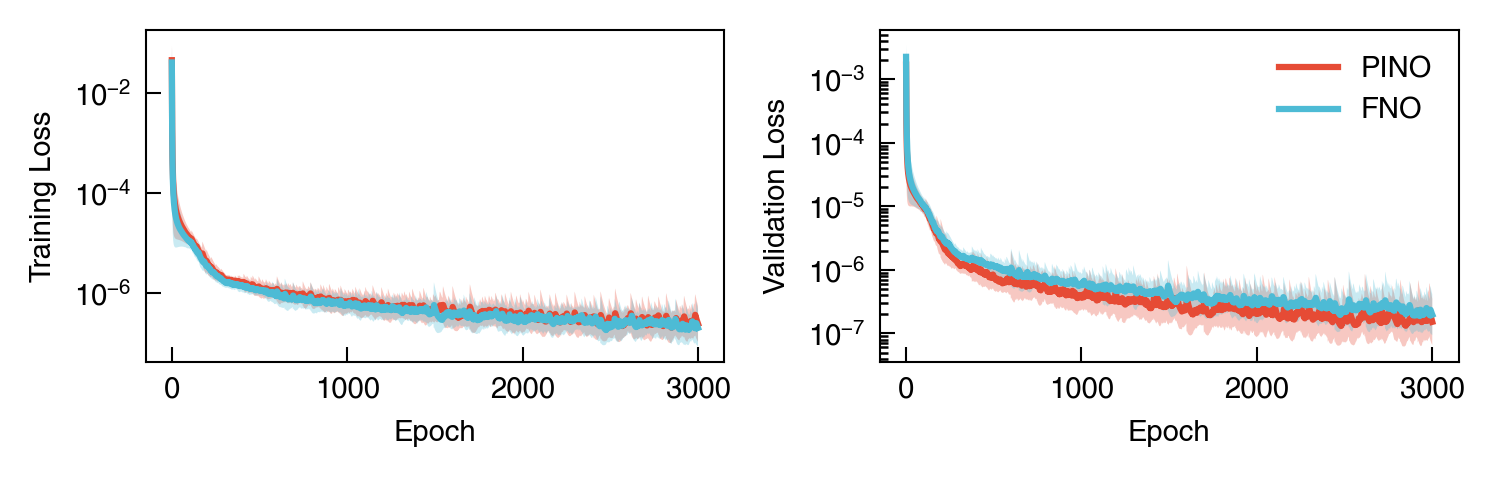

In [3]:
# read csv loss
import pandas as pd
import numpy as np

def moving_average(data, window_size=50, log_scale=False):
    series = pd.Series(data)
    if log_scale:
        series = np.log(series)
        
    # 使用 ewm (指数加权移动平均) 替代 rolling
    # span=window_size，产生的曲线更平滑，阴影边缘也更自然，符合主流论文绘图风格
    mean = series.ewm(span=window_size).mean()
    std = series.ewm(span=window_size).std().fillna(0)
    
    if log_scale:
        avg = np.exp(mean)
        lower = np.exp(mean - std)
        upper = np.exp(mean + std)
    else:
        avg = mean
        lower = mean - std
        upper = mean + std
        
    return avg.values, lower.values, upper.values

save_dir_pino = "/root/autodl-tmp/runs/spinodal_decomp/FNO-PI/"
save_dir_fno = "/root/autodl-tmp/runs/spinodal_decomp/FNO/"
dirs = [
    (save_dir_pino, "PINO"),
    (save_dir_fno, "FNO"),
]

fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    loss_df = loss_df[loss_df["Epoch"] <= 3000]
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    
    avg, lower, upper = moving_average(loss_df["TrainLoss"].values, log_scale=True)
    
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], lower, upper, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    
    avg, lower, upper = moving_average(loss_df["ValidLoss"].values, log_scale=True)
    
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], lower, upper, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()
fig.tight_layout()

Text(0, 0.5, 'Test MSE Loss (100 steps)')

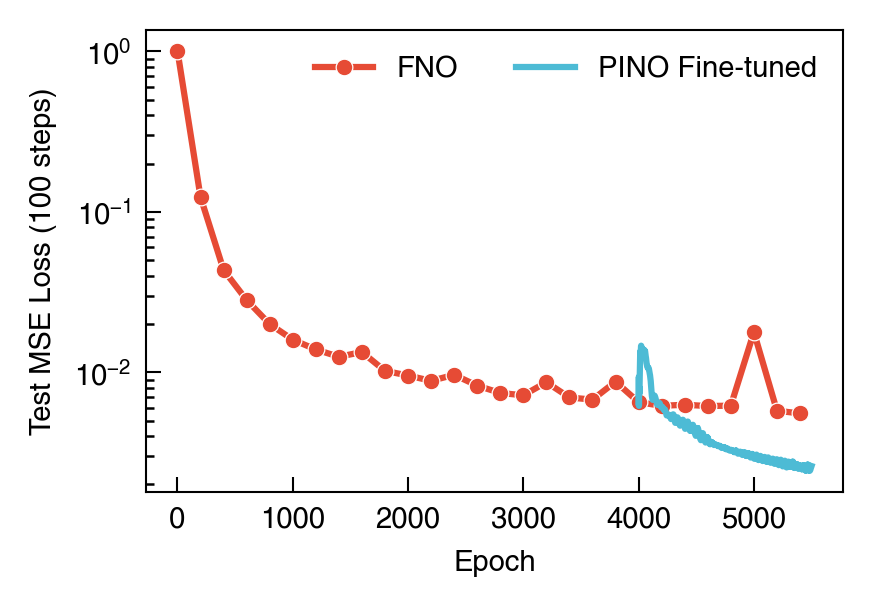

In [4]:

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))


# for dir_path, model_name in dirs:
#     test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
#     ax.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
test_df = pd.read_csv("/root/autodl-tmp/runs/spinodal_decomp/FNO/test_logs.csv")
ax.plot(test_df["Epoch"], test_df["TestMSE"], label="FNO", marker='o', 
        markersize=4, markeredgecolor="white", markeredgewidth=0.3)
fine_tuned_error = np.load("/root/autodl-tmp/runs/spinodal_decomp/FNO/fine_tune_mse_errors.npy")
epochs = np.arange(1, fine_tuned_error.shape[0] + 1) + 4000
ax.plot(epochs, fine_tuned_error, label="PINO Fine-tuned", )
    
ax.legend(ncol=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss (100 steps)")